### Notebook08 — Clustering: Inflation Shock Archetypes (COICOP)

**Goal**
- Identify recurring, economically interpretable **inflation regimes** across European countries by clustering **COICOP category inflation patterns**.

**Main question**
- Do countries fall into distinct “inflation shock archetypes” (e.g., energy-led vs broad-based), and **how do they transition** between archetypes over time?

**What we will do**
- Load the prepared COICOP feature panel at **(geo, timeQuarter)**.
- Build clustering vectors using **CP01–CP12**, preferably as **(country − EU27)** to remove common shocks.
- Fit clustering models (start with **KMeans**; later compare with alternatives if needed).
- Produce interpretability outputs:
  - cluster centroids/prototypes in CP01–CP12 space
  - cluster sizes and evolution over time
  - transition analysis (how countries move between clusters)

**Inputs**
- `data_processed/ml_coicop_features_2010_2024.parquet`
- Optional: `reports/tables/ml_coicop_X_cols_2010_2024.txt`

**Outputs (planned)**
- `reports/tables/ml_cluster_labels_coicop.csv` (geo, timeQuarter, clusterId)
- `reports/tables/ml_cluster_centroids_coicop.csv`
- Clean diagnostic plots saved only after visual confirmation


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

# Repro + display
rngSeed = 42
np.random.seed(rngSeed)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

def findProjectRoot(startPath: Path, markerDir: str = "data_processed", maxUp: int = 6) -> Path:
    p = startPath.resolve()
    for _ in range(maxUp + 1):
        if (p / markerDir).exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    return startPath.resolve()

projectRoot = findProjectRoot(Path.cwd())
dataProcessedDir = projectRoot / "data_processed"
reportsDir = projectRoot / "reports"
tablesDir = reportsDir / "tables"
figuresDir = reportsDir / "figures"

coicopPath = dataProcessedDir / "ml_coicop_features_2010_2024.parquet"

print("projectRoot:", projectRoot)
print("coicopPath exists:", coicopPath.exists(), "|", coicopPath)

dfCoicop = pd.read_parquet(coicopPath)

keyCols = ["geo", "timeQuarter"]
assert all(c in dfCoicop.columns for c in keyCols), f"Missing key columns. Found: {dfCoicop.columns[:20].tolist()}"

# Identify raw COICOP CP01–CP12 level columns and vs_eu27 versions (if present)
cpLevelCols = sorted([c for c in dfCoicop.columns if re.fullmatch(r"hicpInflation_CP\d{2}", c)])
cpVsEu27Cols = sorted([c for c in dfCoicop.columns if re.fullmatch(r"hicpInflation_CP\d{2}_vs_eu27", c)])

print("dfCoicop shape:", dfCoicop.shape)
print("geo nUnique:", dfCoicop["geo"].nunique(), "| timeQuarter nUnique:", dfCoicop["timeQuarter"].nunique())
print("CP level cols:", len(cpLevelCols), cpLevelCols)
print("CP vs EU27 cols:", len(cpVsEu27Cols), cpVsEu27Cols)
display(dfCoicop.head(3))


projectRoot: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income
coicopPath exists: True | /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_processed/ml_coicop_features_2010_2024.parquet
dfCoicop shape: (2160, 341)
geo nUnique: 36 | timeQuarter nUnique: 60
CP level cols: 12 ['hicpInflation_CP01', 'hicpInflation_CP02', 'hicpInflation_CP03', 'hicpInflation_CP04', 'hicpInflation_CP05', 'hicpInflation_CP06', 'hicpInflation_CP07', 'hicpInflation_CP08', 'hicpInflation_CP09', 'hicpInflation_CP10', 'hicpInflation_CP11', 'hicpInflation_CP12']
CP vs EU27 cols: 12 ['hicpInflation_CP01_vs_eu27', 'hicpInflation_CP02_vs_eu27', 'hicpInflation_CP03_vs_eu27', 'hicpInflation_CP04_vs_eu27', 'hicpInflation_CP05_vs_eu27', 'hicpInflation_CP06_vs_eu27', 'hicpInflation_CP07_vs_eu27', 'hicpInflation_CP08_vs_eu27', 'hicpInflation_CP09_vs_eu27', 'hicpInflation_CP10_vs_eu27', 'hicpInflation_CP11_vs_eu27', 'hicpInflation_CP12_vs_eu27']


,geo,timeQuarter,hicpInflation,hicpIndex,employmentIndex,hicpIndex_nMonths,hicpInflation_nMonths,hicp_nMonths_min,hicpInflation_CP01,hicpInflation_CP02,hicpInflation_CP03,hicpInflation_CP04,hicpInflation_CP05,hicpInflation_CP06,hicpInflation_CP07,hicpInflation_CP08,hicpInflation_CP09,hicpInflation_CP10,hicpInflation_CP11,hicpInflation_CP12,eu27_hicpInflation,eu27_employmentIndex,eu27_hicpInflation_CP01,eu27_hicpInflation_CP02,eu27_hicpInflation_CP03,eu27_hicpInflation_CP04,eu27_hicpInflation_CP05,eu27_hicpInflation_CP06,eu27_hicpInflation_CP07,eu27_hicpInflation_CP08,eu27_hicpInflation_CP09,eu27_hicpInflation_CP10,eu27_hicpInflation_CP11,eu27_hicpInflation_CP12,hicpInflation_vs_eu27,employmentIndex_vs_eu27,hicpInflation_CP01_vs_eu27,hicpInflation_CP02_vs_eu27,hicpInflation_CP03_vs_eu27,hicpInflation_CP04_vs_eu27,hicpInflation_CP05_vs_eu27,hicpInflation_CP06_vs_eu27,hicpInflation_CP07_vs_eu27,hicpInflation_CP08_vs_eu27,hicpInflation_CP09_vs_eu27,hicpInflation_CP10_vs_eu27,hicpInflation_CP11_vs_eu27,hicpInflation_CP12_vs_eu27,year,quarter,is_stable_pre_covid,is_covid,is_infl_surge,hicpInflation_lag1,hicpInflation_lag4,hicpInflation_chg_qoq,hicpInflation_chg_yoy,hicpInflation_roll4_mean,hicpInflation_roll4_std,hicpIndex_lag1,...,hicpInflation_CP08_vs_eu27_lag1,hicpInflation_CP08_vs_eu27_lag4,hicpInflation_CP08_vs_eu27_chg_qoq,hicpInflation_CP08_vs_eu27_chg_yoy,hicpInflation_CP08_vs_eu27_roll4_mean,hicpInflation_CP08_vs_eu27_roll4_std,hicpInflation_CP09_vs_eu27_lag1,hicpInflation_CP09_vs_eu27_lag4,hicpInflation_CP09_vs_eu27_chg_qoq,hicpInflation_CP09_vs_eu27_chg_yoy,hicpInflation_CP09_vs_eu27_roll4_mean,hicpInflation_CP09_vs_eu27_roll4_std,hicpInflation_CP10_vs_eu27_lag1,hicpInflation_CP10_vs_eu27_lag4,hicpInflation_CP10_vs_eu27_chg_qoq,hicpInflation_CP10_vs_eu27_chg_yoy,hicpInflation_CP10_vs_eu27_roll4_mean,hicpInflation_CP10_vs_eu27_roll4_std,hicpInflation_CP11_vs_eu27_lag1,hicpInflation_CP11_vs_eu27_lag4,hicpInflation_CP11_vs_eu27_chg_qoq,hicpInflation_CP11_vs_eu27_chg_yoy,hicpInflation_CP11_vs_eu27_roll4_mean,hicpInflation_CP11_vs_eu27_roll4_std,hicpInflation_CP12_vs_eu27_lag1,hicpInflation_CP12_vs_eu27_lag4,hicpInflation_CP12_vs_eu27_chg_qoq,hicpInflation_CP12_vs_eu27_chg_yoy,hicpInflation_CP12_vs_eu27_roll4_mean,hicpInflation_CP12_vs_eu27_roll4_std,year_lag1,year_lag4,year_chg_qoq,year_chg_yoy,year_roll4_mean,year_roll4_std,quarter_lag1,quarter_lag4,quarter_chg_qoq,quarter_chg_yoy,quarter_roll4_mean,quarter_roll4_std,is_stable_pre_covid_lag1,is_stable_pre_covid_lag4,is_stable_pre_covid_chg_qoq,is_stable_pre_covid_chg_yoy,is_stable_pre_covid_roll4_mean,is_stable_pre_covid_roll4_std,is_covid_lag1,is_covid_lag4,is_covid_chg_qoq,is_covid_chg_yoy,is_covid_roll4_mean,is_covid_roll4_std,is_infl_surge_lag1,is_infl_surge_lag4,is_infl_surge_chg_qoq,is_infl_surge_chg_yoy,is_infl_surge_roll4_mean,is_infl_surge_roll4_std
0,AT,2010Q1,1.3,89.41,98.6,3,3,3,-1.333333,0.8,-0.233333,2.5,2.0,2.0,3.933333,0.733333,0.4,-10.9,0.933333,3.133333,1.433333,100.1,-0.633333,6.666667,-0.4,0.4,0.833333,1.333333,5.433333,-0.8,0.066667,1.966667,1.233333,2.166667,-0.133333,-1.5,-0.7,-5.866667,0.166667,2.1,1.166667,0.666667,-1.5,1.533333,0.333333,-12.866667,-0.3,0.966667,2010,1,1,0,0,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,...,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AT,2010Q2,1.766667,90.243333,99.4,3,3,3,0.066667,2.333333,1.7,3.1,1.6,1.8,3.933333,0.9,0.833333,-5.4,0.733333,2.866667,1.733333,100.3,0.033333,6.166667,1.0,2.033333,0.633333,1.2,5.266667,-0.966667,-0.366667,2.0,1.166667,2.1,0.033333,-0.9,0.033333,-3.833333,0.7,1.066667,0.966667,0.6,-1.333333,1.866667,1.2,-7.4,-0.433333,0.766667,2010,2,1,0,0,1.3,<NA>,0.466667,<NA>,NaN,NaN,89.41,...,1.533333,<NA>,0.333333,<NA>,NaN,NaN,0.333333,<NA>,0.866667,<NA>,NaN,NaN,-12.866667,<NA>,5.466667,<NA>,NaN,N

In [2]:
# Build the window/input quickly (same settings as before)
dfCoicop = dfCoicop.copy()
dfCoicop["timeQuarterPeriod"] = pd.PeriodIndex(dfCoicop["timeQuarter"], freq="Q-DEC")

windowPresets = {
    "full2010to2024": ("2010Q1", "2024Q4"),
    "preCovid": ("2010Q1", "2019Q4"),
    "covid": ("2020Q1", "2021Q4"),
    "surge": ("2021Q2", "2022Q4"),
    "surgeAndAfter": ("2021Q2", "2024Q4"),
}

analysisWindowKey = "surgeAndAfter"
startQ, endQ = windowPresets[analysisWindowKey]
startP = pd.Period(startQ, freq="Q-DEC")
endP = pd.Period(endQ, freq="Q-DEC")

dfWindow = dfCoicop.loc[
    (dfCoicop["timeQuarterPeriod"] >= startP) & (dfCoicop["timeQuarterPeriod"] <= endP),
    :
].copy()

cpVectorCols = cpVsEu27Cols if len(cpVsEu27Cols) == 12 else cpLevelCols
assert len(cpVectorCols) == 12, f"Expected 12 CP cols, got {len(cpVectorCols)}"

dfClusterInput = dfWindow[["geo", "timeQuarter", "timeQuarterPeriod"] + cpVectorCols].copy()
dfClusterInput = dfClusterInput.sort_values(["timeQuarterPeriod", "geo"]).reset_index(drop=True)

# Missing rows diagnostics
missingMask = dfClusterInput[cpVectorCols].isna().any(axis=1)
dfMissingRows = dfClusterInput.loc[missingMask, ["geo", "timeQuarter"]].copy()

print("analysisWindowKey:", analysisWindowKey, "|", startQ, "to", endQ)
print("Rows in window:", len(dfClusterInput))
print("Rows with any missing CP value:", int(missingMask.sum()))
if len(dfMissingRows) > 0:
    display(dfMissingRows["geo"].value_counts().to_frame("missingRowsByGeo"))
    display(dfMissingRows.head(20))

# Fix: drop EU aggregates from clustering (we cluster countries, not the bloc aggregate)
euLikeGeos = {"EU27_2020", "EU27", "EA19", "EA"}
dropMask = dfClusterInput["geo"].isin(euLikeGeos)
droppedEu = int(dropMask.sum())

dfClusterInput = dfClusterInput.loc[~dropMask, :].copy()

# If anything else is still missing, drop those rows explicitly (should be rare)
missingMask2 = dfClusterInput[cpVectorCols].isna().any(axis=1)
droppedOther = int(missingMask2.sum())
dfClusterInput = dfClusterInput.loc[~missingMask2, :].copy()

# Final check
nMissingFinal = int(dfClusterInput[cpVectorCols].isna().sum().sum())
assert nMissingFinal == 0, f"Still missing CP values after cleanup: {nMissingFinal}"

X = dfClusterInput[cpVectorCols].to_numpy()

print("Dropped EU-like rows:", droppedEu, "| Dropped other-missing rows:", droppedOther)
print("Final dfClusterInput shape:", dfClusterInput.shape, "| X shape:", X.shape)
print("geo nUnique:", dfClusterInput["geo"].nunique(), "| quarters:", dfClusterInput["timeQuarter"].nunique())
print("Using CP columns:", cpVectorCols)

avgAbsByCat = pd.Series(np.mean(np.abs(X), axis=0), index=cpVectorCols).sort_values(ascending=False)
display(avgAbsByCat.to_frame("avgAbsValue"))
display(dfClusterInput.head(3))


analysisWindowKey: surgeAndAfter | 2021Q2 to 2024Q4
Rows in window: 540
Rows with any missing CP value: 15


,missingRowsByGeo
geo,
UK,15


,geo,timeQuarter
35,UK,2021Q2
71,UK,2021Q3
107,UK,2021Q4
143,UK,2022Q1
179,UK,2022Q2
215,UK,2022Q3
251,UK,2022Q4
287,UK,2023Q1
323,UK,2023Q2
359,UK,2023Q3


Dropped EU-like rows: 45 | Dropped other-missing rows: 15
Final dfClusterInput shape: (480, 15) | X shape: (480, 12)
geo nUnique: 32 | quarters: 15
Using CP columns: ['hicpInflation_CP01_vs_eu27', 'hicpInflation_CP02_vs_eu27', 'hicpInflation_CP03_vs_eu27', 'hicpInflation_CP04_vs_eu27', 'hicpInflation_CP05_vs_eu27', 'hicpInflation_CP06_vs_eu27', 'hicpInflation_CP07_vs_eu27', 'hicpInflation_CP08_vs_eu27', 'hicpInflation_CP09_vs_eu27', 'hicpInflation_CP10_vs_eu27', 'hicpInflation_CP11_vs_eu27', 'hicpInflation_CP12_vs_eu27']


,avgAbsValue
hicpInflation_CP04_vs_eu27,6.396319
hicpInflation_CP10_vs_eu27,3.310556
hicpInflation_CP11_vs_eu27,2.837917
hicpInflation_CP08_vs_eu27,2.822708
hicpInflation_CP01_vs_eu27,2.795625
hicpInflation_CP07_vs_eu27,2.777569
hicpInflation_CP02_vs_eu27,2.327222
hicpInflation_CP06_vs_eu27,2.232917
hicpInflation_CP12_vs_eu27,2.162569
hicpInflation_CP03_vs_eu27,2.153681


,geo,timeQuarter,timeQuarterPeriod,hicpInflation_CP01_vs_eu27,hicpInflation_CP02_vs_eu27,hicpInflation_CP03_vs_eu27,hicpInflation_CP04_vs_eu27,hicpInflation_CP05_vs_eu27,hicpInflation_CP06_vs_eu27,hicpInflation_CP07_vs_eu27,hicpInflation_CP08_vs_eu27,hicpInflation_CP09_vs_eu27,hicpInflation_CP10_vs_eu27,hicpInflation_CP11_vs_eu27,hicpInflation_CP12_vs_eu27
0,AT,2021Q2,2021Q2,0.333333,-0.966667,1.633333,-0.8,1.4,0.766667,-2.433333,-1.733333,1.833333,1.066667,3.233333,-0.866667
1,BE,2021Q2,2021Q2,-1.566667,2.3,-0.4,4.0,-0.9,-1.0,-0.566667,1.7,-0.233333,-0.333333,1.166667,-1.033333
2,BG,2021Q2,2021Q2,0.533333,-2.333333,-2.533333,-0.433333,0.5,0.033333,1.466667,-1.133333,3.533333,3.966667,-0.666667,1.5


In [3]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- Scaling choice (default robust) ---
scaleMethod = "robust"  # "robust" or "standard"
scaler = RobustScaler() if scaleMethod == "robust" else StandardScaler()

XScaled = scaler.fit_transform(X)

# --- K sweep ---
kList = list(range(2, 11))
rows = []
for k in kList:
    km = KMeans(n_clusters=k, random_state=rngSeed, n_init=20)
    labels = km.fit_predict(XScaled)

    rows.append({
        "k": k,
        "silhouette": float(silhouette_score(XScaled, labels)),
        "calinskiHarabasz": float(calinski_harabasz_score(XScaled, labels)),
        "daviesBouldin": float(davies_bouldin_score(XScaled, labels)),
        "inertia": float(km.inertia_),
    })

metricsDf = pd.DataFrame(rows).sort_values("silhouette", ascending=False).reset_index(drop=True)

print("analysisWindowKey:", analysisWindowKey, "| scaleMethod:", scaleMethod)
display(metricsDf)

# Also show the best k by silhouette as a quick anchor
bestRow = metricsDf.iloc[0].to_dict()
print("Best by silhouette:", bestRow)


analysisWindowKey: surgeAndAfter | scaleMethod: robust


,k,silhouette,calinskiHarabasz,daviesBouldin,inertia
0,2,0.349748,153.221775,1.424926,5460.547845
1,3,0.346792,179.773280,0.987085,4111.672864
2,5,0.263705,145.663563,1.005817,3238.472265
3,4,0.191121,156.164130,1.349066,3634.115961
4,6,0.145167,135.403283,1.342416,2969.525897
5,7,0.130901,123.882090,1.489807,2804.228444
6,10,0.118212,98.825744,1.549767,2493.048680
7,9,0.117316,105.335951,1.470906,2585.348512
8,8,0.114518,113.745767,1.567203,2683.722244


Best by silhouette: {'k': 2.0, 'silhouette': 0.34974786245752754, 'calinskiHarabasz': 153.22177479132876, 'daviesBouldin': 1.424926169515196, 'inertia': 5460.547845050449}


In [4]:
# --- Fit final KMeans (initial choice) + build interpretable prototypes ---

kChosen = 3  # start here; we'll sanity-check sizes + interpretability
kmFinal = KMeans(n_clusters=kChosen, random_state=rngSeed, n_init=50)

clusterId = kmFinal.fit_predict(XScaled)

dfClusterLabeled = dfClusterInput.copy()
dfClusterLabeled["clusterId"] = clusterId

# Cluster sizes (overall and by quarter)
clusterCounts = (
    dfClusterLabeled["clusterId"]
    .value_counts()
    .sort_index()
    .rename("nRows")
    .to_frame()
)
clusterCounts["share"] = clusterCounts["nRows"] / clusterCounts["nRows"].sum()

clusterCountsByQuarter = (
    dfClusterLabeled.groupby(["timeQuarter", "clusterId"], as_index=False)
    .size()
    .rename(columns={"size": "nRows"})
)

# Interpretable prototypes: mean CP vector per cluster in ORIGINAL units (vs EU27)
centroidDf = (
    dfClusterLabeled.groupby("clusterId")[cpVectorCols]
    .mean()
    .sort_index()
)

# Quick “dominant categories” per cluster (top +/- by absolute mean)
dominantRows = []
for cid in centroidDf.index:
    s = centroidDf.loc[cid].copy()
    topPos = s.sort_values(ascending=False).head(3)
    topNeg = s.sort_values(ascending=True).head(3)
    dominantRows.append({
        "clusterId": int(cid),
        "topPositiveCats": ", ".join([f"{i}:{v:.2f}" for i, v in topPos.items()]),
        "topNegativeCats": ", ".join([f"{i}:{v:.2f}" for i, v in topNeg.items()]),
    })
dominantDf = pd.DataFrame(dominantRows).sort_values("clusterId")

print("kChosen:", kChosen)
display(clusterCounts)
display(dominantDf)
display(centroidDf.round(3))


kChosen: 3


,nRows,share
clusterId,,
0,4,0.008333
1,115,0.239583
2,361,0.752083


,clusterId,topPositiveCats,topNegativeCats
0,0,"hicpInflation_CP10_vs_eu27:72.12, hicpInflatio...","hicpInflation_CP04_vs_eu27:-6.14, hicpInflatio..."
1,1,"hicpInflation_CP04_vs_eu27:6.31, hicpInflation...","hicpInflation_CP02_vs_eu27:2.02, hicpInflation..."
2,2,"hicpInflation_CP08_vs_eu27:-0.10, hicpInflatio...","hicpInflation_CP01_vs_eu27:-1.16, hicpInflatio..."


,hicpInflation_CP01_vs_eu27,hicpInflation_CP02_vs_eu27,hicpInflation_CP03_vs_eu27,hicpInflation_CP04_vs_eu27,hicpInflation_CP05_vs_eu27,hicpInflation_CP06_vs_eu27,hicpInflation_CP07_vs_eu27,hicpInflation_CP08_vs_eu27,hicpInflation_CP09_vs_eu27,hicpInflation_CP10_vs_eu27,hicpInflation_CP11_vs_eu27,hicpInflation_CP12_vs_eu27
clusterId,,,,,,,,,,,,
0,-1.183,-1.175,4.483,-6.142,-0.075,0.567,-2.05,-2.125,-0.575,72.117,0.25,0.25
1,4.782,2.02,3.094,6.307,3.576,4.137,2.847,2.879,3.275,2.894,6.269,4.574
2,-1.163,-1.037,-0.567,-0.524,-0.505,-0.371,-0.378,-0.096,-0.34,-0.847,-0.333,-0.919


In [5]:
# --- Diagnose the tiny outlier cluster (clusterId==0) ---
outlierClusterId = 0

dfOutlier = dfClusterLabeled.loc[dfClusterLabeled["clusterId"] == outlierClusterId, :].copy()

print("Outlier cluster rows:", len(dfOutlier))
display(dfOutlier["geo"].value_counts().to_frame("nRowsByGeo"))
display(dfOutlier[["geo", "timeQuarter"] + cpVectorCols].sort_values(["geo", "timeQuarter"]))

# Which CP features are extreme in these rows?
absVals = dfOutlier[cpVectorCols].abs()
extremeSummary = pd.DataFrame({
    "maxAbs": absVals.max(axis=0),
    "meanAbs": absVals.mean(axis=0),
}).sort_values("maxAbs", ascending=False)

display(extremeSummary.head(12))

# Quick global quantiles for the most suspicious feature(s)
topSuspiciousCols = extremeSummary.index[:3].tolist()
quantDf = pd.DataFrame({
    col: dfClusterLabeled[col].quantile([0.0, 0.01, 0.05, 0.50, 0.95, 0.99, 1.0])
    for col in topSuspiciousCols
}).rename_axis("quantile")
display(quantDf)


Outlier cluster rows: 4


,nRowsByGeo
geo,
NL,4


,geo,timeQuarter,hicpInflation_CP01_vs_eu27,hicpInflation_CP02_vs_eu27,hicpInflation_CP03_vs_eu27,hicpInflation_CP04_vs_eu27,hicpInflation_CP05_vs_eu27,hicpInflation_CP06_vs_eu27,hicpInflation_CP07_vs_eu27,hicpInflation_CP08_vs_eu27,hicpInflation_CP09_vs_eu27,hicpInflation_CP10_vs_eu27,hicpInflation_CP11_vs_eu27,hicpInflation_CP12_vs_eu27
242,NL,2022Q4,-2.333333,-3.2,4.1,14.766667,1.266667,-0.9,-3.4,-2.8,-0.9,78.266667,0.466667,-0.366667
278,NL,2023Q1,-1.1,-3.9,5.0,-11.533333,-0.1,0.433333,-3.266667,-2.4,-0.366667,78.266667,0.233333,0.466667
314,NL,2023Q2,-0.6,-2.266667,6.066667,-9.9,-0.266667,1.566667,-0.966667,-2.0,-0.4,78.533333,-0.766667,0.533333
350,NL,2023Q3,-0.7,4.666667,2.766667,-17.9,-1.2,1.166667,-0.566667,-1.3,-0.633333,53.4,1.066667,0.366667


,maxAbs,meanAbs
hicpInflation_CP10_vs_eu27,78.533333,72.116667
hicpInflation_CP04_vs_eu27,17.9,13.525
hicpInflation_CP03_vs_eu27,6.066667,4.483333
hicpInflation_CP02_vs_eu27,4.666667,3.508333
hicpInflation_CP07_vs_eu27,3.4,2.05
hicpInflation_CP08_vs_eu27,2.8,2.125
hicpInflation_CP01_vs_eu27,2.333333,1.183333
hicpInflation_CP06_vs_eu27,1.566667,1.016667
hicpInflation_CP05_vs_eu27,1.266667,0.708333
hicpInflation_CP11_vs_eu27,1.066667,0.633333


,hicpInflation_CP10_vs_eu27,hicpInflation_CP04_vs_eu27,hicpInflation_CP03_vs_eu27
quantile,,,
0.00,-45.7,-24.366667,-8.633333
0.01,-12.087667,-19.162,-6.080667
0.05,-4.435,-11.536667,-3.403333
0.50,0.4,-0.333333,-0.033333
0.95,5.548333,18.368333,5.14
0.99,16.218333,33.636667,9.889
1.00,78.533333,53.766667,17.666667


In [6]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- Winsorize CP vectors to reduce outlier domination ---
clipQuantileLow = 0.01
clipQuantileHigh = 0.99

clipLower = dfClusterInput[cpVectorCols].quantile(clipQuantileLow)
clipUpper = dfClusterInput[cpVectorCols].quantile(clipQuantileHigh)

dfClusterInputClipped = dfClusterInput.copy()
dfClusterInputClipped[cpVectorCols] = dfClusterInputClipped[cpVectorCols].clip(lower=clipLower, upper=clipUpper, axis=1)

# Quick check: did we tame CP10?
cp10Col = "hicpInflation_CP10_vs_eu27"
if cp10Col in cpVectorCols:
    beforeMax = float(dfClusterInput[cp10Col].abs().max())
    afterMax = float(dfClusterInputClipped[cp10Col].abs().max())
    print("CP10 maxAbs before:", beforeMax, "| after:", afterMax)

XClipped = dfClusterInputClipped[cpVectorCols].to_numpy()

# Scale (robust)
scaler = RobustScaler()
XScaledClipped = scaler.fit_transform(XClipped)

# --- K sweep again ---
kList = list(range(2, 11))
rows = []
for k in kList:
    km = KMeans(n_clusters=k, random_state=rngSeed, n_init=20)
    labels = km.fit_predict(XScaledClipped)
    rows.append({
        "k": k,
        "silhouette": float(silhouette_score(XScaledClipped, labels)),
        "calinskiHarabasz": float(calinski_harabasz_score(XScaledClipped, labels)),
        "daviesBouldin": float(davies_bouldin_score(XScaledClipped, labels)),
        "inertia": float(km.inertia_),
    })

metricsDfClipped = pd.DataFrame(rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("analysisWindowKey:", analysisWindowKey, "| clipping:", (clipQuantileLow, clipQuantileHigh), "| scaling: robust")
display(metricsDfClipped)

# --- Fit k=3 again (same interpretability target) ---
kChosen = 3
kmFinal = KMeans(n_clusters=kChosen, random_state=rngSeed, n_init=50)
clusterId = kmFinal.fit_predict(XScaledClipped)

dfClusterLabeled = dfClusterInputClipped.copy()
dfClusterLabeled["clusterId"] = clusterId

clusterCounts = (
    dfClusterLabeled["clusterId"]
    .value_counts()
    .sort_index()
    .rename("nRows")
    .to_frame()
)
clusterCounts["share"] = clusterCounts["nRows"] / clusterCounts["nRows"].sum()

centroidDf = (
    dfClusterLabeled.groupby("clusterId")[cpVectorCols]
    .mean()
    .sort_index()
)

dominantRows = []
for cid in centroidDf.index:
    s = centroidDf.loc[cid].copy()
    topPos = s.sort_values(ascending=False).head(3)
    topNeg = s.sort_values(ascending=True).head(3)
    dominantRows.append({
        "clusterId": int(cid),
        "topPositiveCats": ", ".join([f"{i}:{v:.2f}" for i, v in topPos.items()]),
        "topNegativeCats": ", ".join([f"{i}:{v:.2f}" for i, v in topNeg.items()]),
    })
dominantDf = pd.DataFrame(dominantRows).sort_values("clusterId")

print("kChosen:", kChosen)
display(clusterCounts)
display(dominantDf)


CP10 maxAbs before: 78.53333333333333 | after: 16.218333333333295
analysisWindowKey: surgeAndAfter | clipping: (0.01, 0.99) | scaling: robust


,k,silhouette,calinskiHarabasz,daviesBouldin,inertia
0,2,0.342856,216.915459,1.290431,3425.529886
1,3,0.193327,159.111643,1.718106,2987.178173
2,4,0.125773,125.162538,1.930508,2783.943748
3,9,0.121186,72.860427,1.873440,2225.666938
4,7,0.117837,83.145720,2.039557,2423.722370
5,10,0.115683,68.700001,1.816669,2150.706078
6,8,0.114785,77.930491,1.892934,2310.115434
7,6,0.108938,93.082452,1.992738,2512.777040
8,5,0.105349,105.816250,2.004805,2633.425092


kChosen: 3


,nRows,share
clusterId,,
0,148,0.308333
1,275,0.572917
2,57,0.118750


,clusterId,topPositiveCats,topNegativeCats
0,0,"hicpInflation_CP10_vs_eu27:2.59, hicpInflation...","hicpInflation_CP04_vs_eu27:0.42, hicpInflation..."
1,1,"hicpInflation_CP08_vs_eu27:-0.28, hicpInflatio...","hicpInflation_CP02_vs_eu27:-1.70, hicpInflatio..."
2,2,"hicpInflation_CP04_vs_eu27:10.99, hicpInflatio...","hicpInflation_CP02_vs_eu27:2.27, hicpInflation..."


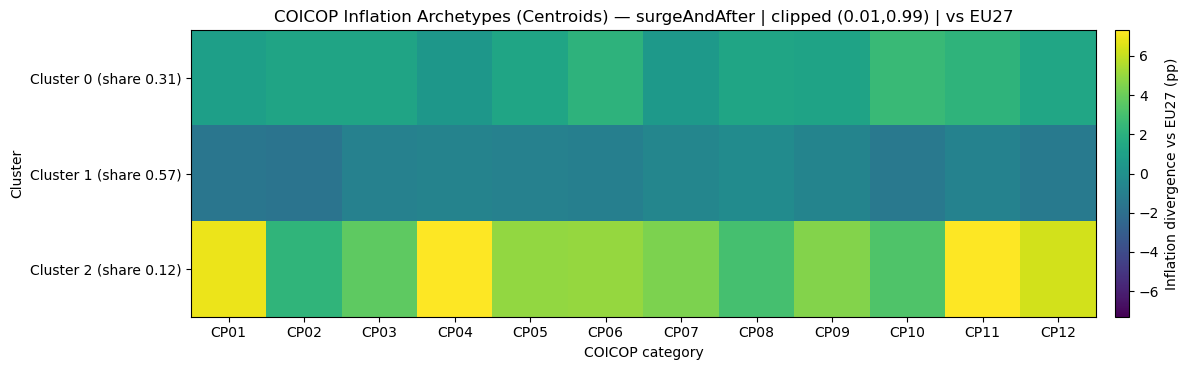

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# --- Clean prototype heatmap (centroids) with numeric coercion ---
centroidPlotDf = centroidDf.copy()

# Force numeric (coerce anything weird to NaN, then assert none remain)
centroidPlotDf = centroidPlotDf.apply(pd.to_numeric, errors="coerce")
assert centroidPlotDf.isna().sum().sum() == 0, "Centroid table has NaNs after numeric coercion."

# Shorten column labels to CP01..CP12
shortCols = []
for c in centroidPlotDf.columns:
    m = re.search(r"(CP\d{2})", c)
    shortCols.append(m.group(1) if m else c)
centroidPlotDf.columns = shortCols

# Add share info to row labels
clusterShareMap = clusterCounts["share"].to_dict()
rowLabels = [f"Cluster {cid} (share {clusterShareMap.get(cid, np.nan):.2f})" for cid in centroidPlotDf.index]

M = centroidPlotDf.to_numpy(dtype=float)

# Robust symmetric color scale around 0 (signed divergences)
valueMaxAbs = float(np.quantile(np.abs(M), 0.95))
norm = TwoSlopeNorm(vmin=-valueMaxAbs, vcenter=0.0, vmax=valueMaxAbs)

fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(M, aspect="auto", norm=norm)

ax.set_title(f"COICOP Inflation Archetypes (Centroids) — {analysisWindowKey} | clipped (0.01,0.99) | vs EU27")
ax.set_xlabel("COICOP category")
ax.set_ylabel("Cluster")

ax.set_xticks(range(len(centroidPlotDf.columns)))
ax.set_xticklabels(centroidPlotDf.columns, rotation=0)
ax.set_yticks(range(len(rowLabels)))
ax.set_yticklabels(rowLabels)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Inflation divergence vs EU27 (pp)")

plt.tight_layout()
#plt.show()


Saved tables:
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_labels.csv
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_centroids.csv
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_clusterCounts.csv


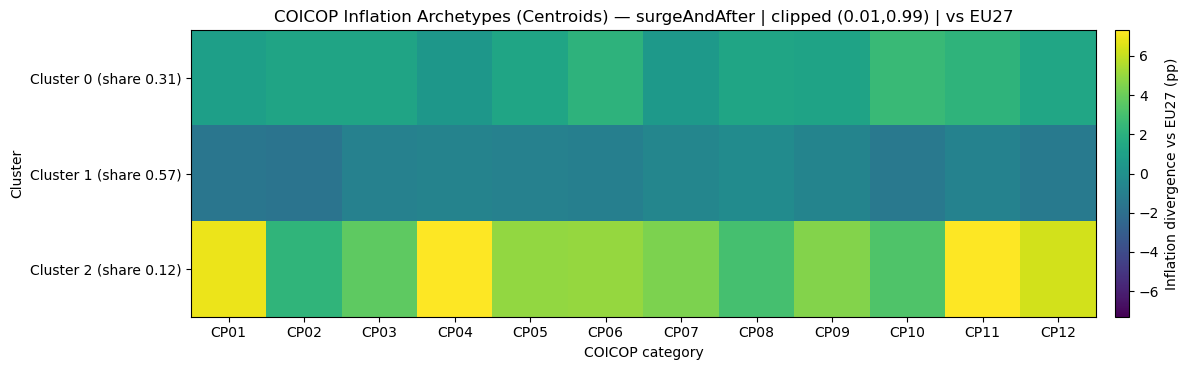

Saved figures:
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_centroidHeatmap.png


In [8]:
# --- Save: centroid heatmap + cluster tables (Notebook08) ---

tablesDir.mkdir(parents=True, exist_ok=True)
figuresDir.mkdir(parents=True, exist_ok=True)

clipTag = "clip01_99"
fileStem = f"ml08_coicopClusters_{analysisWindowKey}_k{kChosen}_{clipTag}_vsEu27"

# 1) Save tables
labelsOutPath = tablesDir / "ml_clustering" / f"{fileStem}_labels.csv"
centroidsOutPath = tablesDir / "ml_clustering" / f"{fileStem}_centroids.csv"
countsOutPath = tablesDir / "ml_clustering" / f"{fileStem}_clusterCounts.csv"

dfClusterLabeled[["geo", "timeQuarter", "clusterId"]].to_csv(labelsOutPath, index=False)
centroidDf.reset_index().to_csv(centroidsOutPath, index=False)
clusterCounts.reset_index().to_csv(countsOutPath, index=False)

print("Saved tables:")
print(" -", labelsOutPath)
print(" -", centroidsOutPath)
print(" -", countsOutPath)

# 2) Recreate + save the centroid heatmap
centroidPlotDf = centroidDf.copy().apply(pd.to_numeric, errors="coerce")
assert centroidPlotDf.isna().sum().sum() == 0

shortCols = []
for c in centroidPlotDf.columns:
    m = re.search(r"(CP\d{2})", c)
    shortCols.append(m.group(1) if m else c)
centroidPlotDf.columns = shortCols

clusterShareMap = clusterCounts.set_index("clusterId")["share"].to_dict() if "clusterId" in clusterCounts.columns else clusterCounts["share"].to_dict()
rowLabels = [f"Cluster {cid} (share {clusterShareMap.get(cid, np.nan):.2f})" for cid in centroidPlotDf.index]

M = centroidPlotDf.to_numpy(dtype=float)
valueMaxAbs = float(np.quantile(np.abs(M), 0.95))
norm = TwoSlopeNorm(vmin=-valueMaxAbs, vcenter=0.0, vmax=valueMaxAbs)

fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(M, aspect="auto", norm=norm)

ax.set_title(f"COICOP Inflation Archetypes (Centroids) — {analysisWindowKey} | clipped (0.01,0.99) | vs EU27")
ax.set_xlabel("COICOP category")
ax.set_ylabel("Cluster")
ax.set_xticks(range(len(centroidPlotDf.columns)))
ax.set_xticklabels(centroidPlotDf.columns, rotation=0)
ax.set_yticks(range(len(rowLabels)))
ax.set_yticklabels(rowLabels)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Inflation divergence vs EU27 (pp)")
plt.tight_layout()

figPathPng = figuresDir / "ml_clustering"/ f"{fileStem}_centroidHeatmap.png"
fig.savefig(figPathPng, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" -", figPathPng)


COICOP cluster centroids — inflation archetypes vs EU27 (surgeAndAfter)

- The heatmap shows **cluster centroids** (prototype vectors) across **COICOP CP01–CP12**.
- Values are **inflation divergences vs EU27** in percentage points (pp):  
  - positive = that category tends to inflate **more than EU27** for observations in the cluster  
  - negative = that category tends to inflate **less than EU27**
- Analysis window: **2021Q2–2024Q4** (surgeAndAfter), excluding EU aggregates and dropping rows with missing CP vectors (UK in this window).
- Robustness step: CP vectors were **winsorized (clipped) at (0.01, 0.99)** before scaling to prevent rare extremes (e.g., NL CP10) from dominating the clustering.
- Interpretation guide:
  - Compare rows to identify which cluster represents **broad-based above-EU inflation** (mostly positive across CPs),
  - which is **broad-based below-EU** (mostly negative),
  - and which represents a **targeted divergence** (a few categories strongly positive/negative).


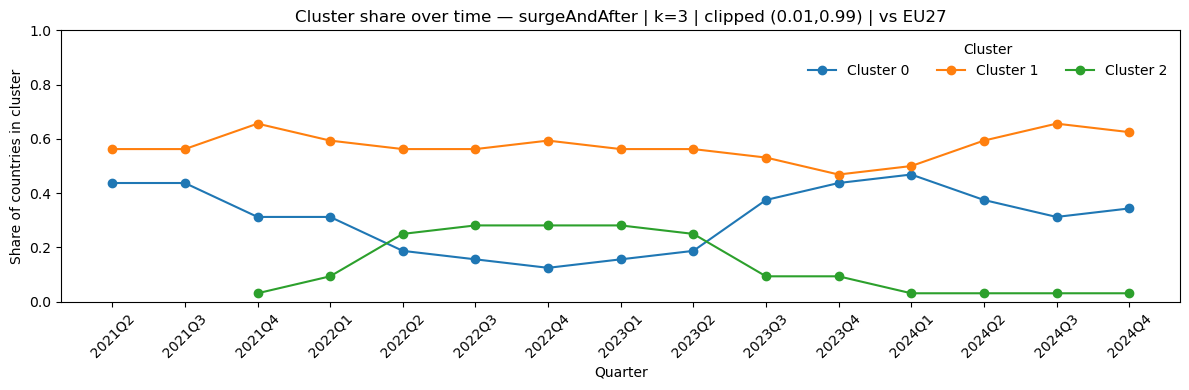

In [11]:
# --- Cluster share over time (plot only, no saving yet) ---

dfShareByQuarter = (
    dfClusterLabeled.groupby(["timeQuarterPeriod", "clusterId"], as_index=False)
    .size()
    .rename(columns={"size": "nRows"})
)

dfTotalByQuarter = (
    dfClusterLabeled.groupby(["timeQuarterPeriod"], as_index=False)
    .size()
    .rename(columns={"size": "nTotal"})
)

dfShareByQuarter = dfShareByQuarter.merge(dfTotalByQuarter, on="timeQuarterPeriod", how="left")
dfShareByQuarter["share"] = dfShareByQuarter["nRows"] / dfShareByQuarter["nTotal"]

shareWide = (
    dfShareByQuarter.pivot(index="timeQuarterPeriod", columns="clusterId", values="share")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 4))

for cid in shareWide.columns:
    ax.plot(shareWide.index.astype(str), shareWide[cid], marker="o", linewidth=1.5, label=f"Cluster {cid}")

ax.set_title(f"Cluster share over time — {analysisWindowKey} | k={kChosen} | clipped (0.01,0.99) | vs EU27")
ax.set_xlabel("Quarter")
ax.set_ylabel("Share of countries in cluster")
ax.set_ylim(0, 1)

# Keep ticks readable (15 quarters max here, but still rotate a bit)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Cluster", ncol=3, frameon=False)

plt.tight_layout()
#plt.show()

#display(dfShareByQuarter.head(10))


Saved tables:
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_clusterShareByQuarter_long.csv
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_clusterShareByQuarter_wide.csv


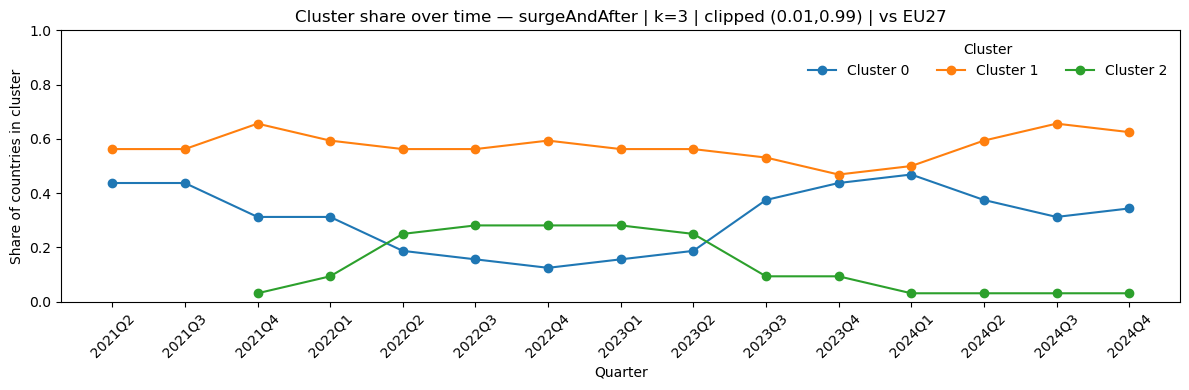

Saved figures:
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_clusterShareOverTime.png
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_clusterShareOverTime.pdf


In [ ]:
# --- Save: cluster share over time plot + table (ml_clustering paths) ---

tablesClusteringDir = tablesDir / "ml_clustering"
figuresClusteringDir = figuresDir / "ml_clustering"
tablesClusteringDir.mkdir(parents=True, exist_ok=True)
figuresClusteringDir.mkdir(parents=True, exist_ok=True)

clipTag = "clip01_99"
fileStem = f"ml08_coicopClusters_{analysisWindowKey}_k{kChosen}_{clipTag}_vsEu27"

# Save share table (long + wide)
shareLongOutPath = tablesClusteringDir / f"{fileStem}_clusterShareByQuarter_long.csv"
shareWideOutPath = tablesClusteringDir / f"{fileStem}_clusterShareByQuarter_wide.csv"

dfShareByQuarter.assign(timeQuarter=dfShareByQuarter["timeQuarterPeriod"].astype(str)).drop(columns=["timeQuarterPeriod"]).to_csv(shareLongOutPath, index=False)
shareWide.assign(timeQuarter=shareWide.index.astype(str)).reset_index(drop=True).to_csv(shareWideOutPath, index=False)

print("Saved tables:")
print(" -", shareLongOutPath)
print(" -", shareWideOutPath)

# Recreate and save the plot (same as displayed)
fig, ax = plt.subplots(figsize=(12, 4))
for cid in shareWide.columns:
    ax.plot(shareWide.index.astype(str), shareWide[cid], marker="o", linewidth=1.5, label=f"Cluster {cid}")

ax.set_title(f"Cluster share over time — {analysisWindowKey} | k={kChosen} | clipped (0.01,0.99) | vs EU27")
ax.set_xlabel("Quarter")
ax.set_ylabel("Share of countries in cluster")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Cluster", ncol=3, frameon=False)

plt.tight_layout()

figPathPng = figuresClusteringDir / f"{fileStem}_clusterShareOverTime.png"
fig.savefig(figPathPng, dpi=200, bbox_inches="tight")
fig.savefig(figPathPdf, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" -", figPathPng)


Transition matrix — quarter-to-quarter switching between inflation archetypes

- The heatmap reports **transition probabilities** from cluster membership at quarter **t-1** (rows) to quarter **t** (columns).
- Probabilities are computed by tracking each country’s cluster assignment over time and counting **geo-level transitions** between consecutive quarters.

- Key takeaways (surgeAndAfter window):
  - Cluster **1** is highly persistent: countries remain in Cluster 1 about **94%** of the time from one quarter to the next.
  - Cluster **0** is moderately persistent (**~79%** stay), with the main movement from **0 → 1** (**~13%**).
  - Cluster **2** is also persistent (**~82%** stay), and when it breaks it tends to move to **2 → 0** (**~18%**), with almost no direct moves to Cluster 1.

- Interpretation note:
  - High diagonal values mean the archetypes behave like **regimes** rather than noisy labels.
  - Off-diagonal probabilities highlight the **common pathways** countries follow as the inflation composition evolves relative to EU27.


In [15]:
# --- Dashboard-ready snapshot: latest quarter membership + top examples ---

latestQuarter = dfClusterLabeled["timeQuarterPeriod"].max()
dfLatest = dfClusterLabeled.loc[dfClusterLabeled["timeQuarterPeriod"] == latestQuarter, :].copy()

print("latestQuarter:", str(latestQuarter), "| nCountries:", dfLatest["geo"].nunique())
display(dfLatest[["geo", "timeQuarterPeriod", "clusterId"]].sort_values(["clusterId", "geo"]))

# Count countries per cluster in latest quarter
latestCounts = (
    dfLatest["clusterId"]
    .value_counts()
    .sort_index()
    .rename("nCountries")
    .to_frame()
)
latestCounts["share"] = latestCounts["nCountries"] / latestCounts["nCountries"].sum()
display(latestCounts)

# Show example countries per cluster (alphabetical)
examplesPerCluster = (
    dfLatest.groupby("clusterId")["geo"]
    .apply(lambda s: ", ".join(sorted(s.tolist())))
    .rename("countries")
    .to_frame()
    .reset_index()
)
display(examplesPerCluster)


latestQuarter: 2024Q4 | nCountries: 32


,geo,timeQuarterPeriod,clusterId
505,BE,2024Q4,0
509,CZ,2024Q4,0
510,DE,2024Q4,0
515,EE,2024Q4,0
521,HR,2024Q4,0
522,HU,2024Q4,0
528,LV,2024Q4,0
530,NL,2024Q4,0
532,PL,2024Q4,0
535,RS,2024Q4,0


,nCountries,share
clusterId,,
0,11,0.34375
1,20,0.62500
2,1,0.03125


,clusterId,countries
0,0,"BE, CZ, DE, EE, HR, HU, LV, NL, PL, RS, SK"
1,1,"AT, BG, CH, CY, DK, EA20, EL, ES, FI, FR, IE, ..."
2,2,RO


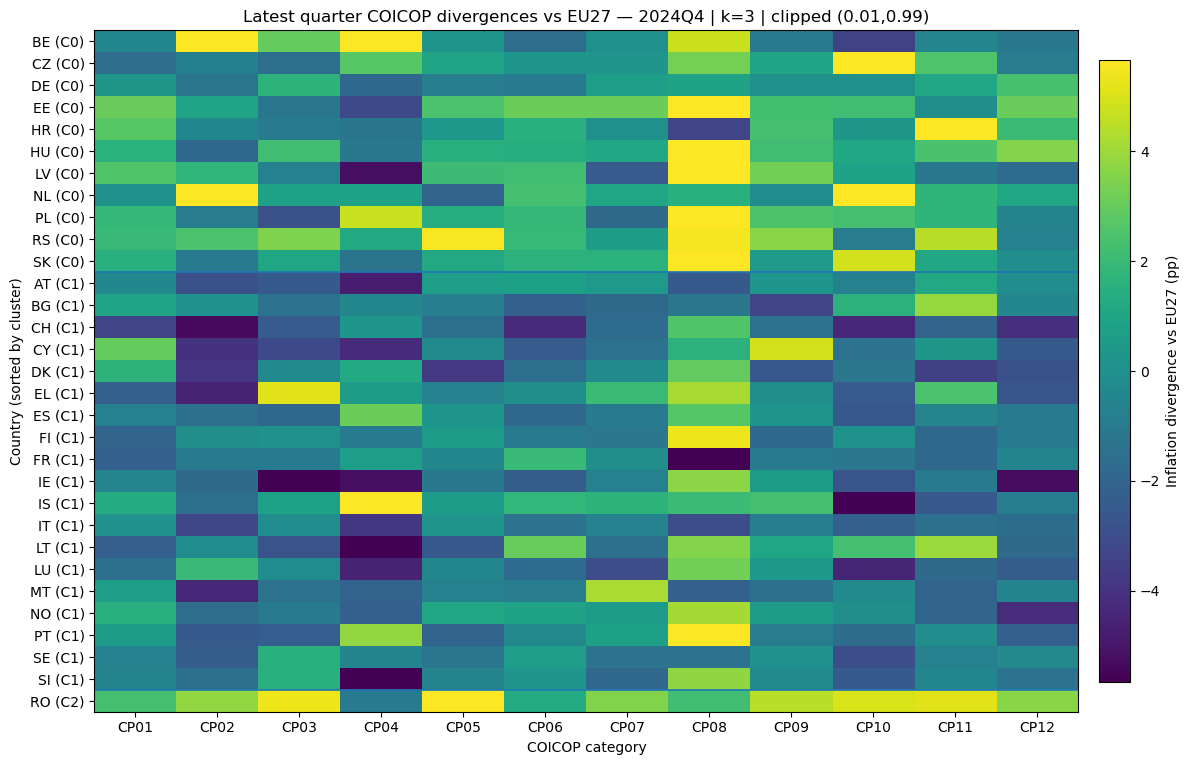

Latest quarter countries plotted: 31 | dropped aggregates: 1


In [16]:
# --- Latest quarter: country × COICOP heatmap, sorted by cluster (plot only) ---

latestQuarter = dfClusterLabeled["timeQuarterPeriod"].max()
dfLatest = dfClusterLabeled.loc[dfClusterLabeled["timeQuarterPeriod"] == latestQuarter, :].copy()

# Drop aggregates like EA/EU for country-style display (keeps plot interpretable)
isAggregate = dfLatest["geo"].astype(str).str.startswith(("EU", "EA"))
dfLatestPlot = dfLatest.loc[~isAggregate, :].copy()

# Prepare matrix: rows = geo (sorted by cluster then geo), cols = CP01..CP12
dfLatestPlot = dfLatestPlot.sort_values(["clusterId", "geo"]).reset_index(drop=True)

matDf = dfLatestPlot[["geo", "clusterId"] + cpVectorCols].copy()
matDf[cpVectorCols] = matDf[cpVectorCols].apply(pd.to_numeric, errors="coerce")
assert matDf[cpVectorCols].isna().sum().sum() == 0, "NaNs found in latest-quarter CP matrix."

# Short column labels
shortCols = []
for c in cpVectorCols:
    m = re.search(r"(CP\d{2})", c)
    shortCols.append(m.group(1) if m else c)

M = matDf[cpVectorCols].to_numpy(dtype=float)

# Robust symmetric color scale
valueMaxAbs = float(np.quantile(np.abs(M), 0.95))
norm = TwoSlopeNorm(vmin=-valueMaxAbs, vcenter=0.0, vmax=valueMaxAbs)

fig, ax = plt.subplots(figsize=(12, max(4, 0.25 * len(matDf))))
im = ax.imshow(M, aspect="auto", norm=norm)

ax.set_title(f"Latest quarter COICOP divergences vs EU27 — {str(latestQuarter)} | k={kChosen} | clipped (0.01,0.99)")
ax.set_xlabel("COICOP category")
ax.set_ylabel("Country (sorted by cluster)")

ax.set_xticks(range(len(shortCols)))
ax.set_xticklabels(shortCols)

# Y labels with cluster id
yLabels = [f"{g} (C{cid})" for g, cid in zip(matDf["geo"], matDf["clusterId"])]
ax.set_yticks(range(len(yLabels)))
ax.set_yticklabels(yLabels)

# Draw horizontal separators between clusters
clusterChangeIdx = np.where(matDf["clusterId"].to_numpy()[1:] != matDf["clusterId"].to_numpy()[:-1])[0]
for idx in clusterChangeIdx:
    ax.axhline(idx + 0.5, linewidth=1.2)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Inflation divergence vs EU27 (pp)")

plt.tight_layout()
plt.show()

print("Latest quarter countries plotted:", matDf["geo"].nunique(), "| dropped aggregates:", int(isAggregate.sum()))


Saved table: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_latestQuarter_2024Q4_countryMatrix.csv


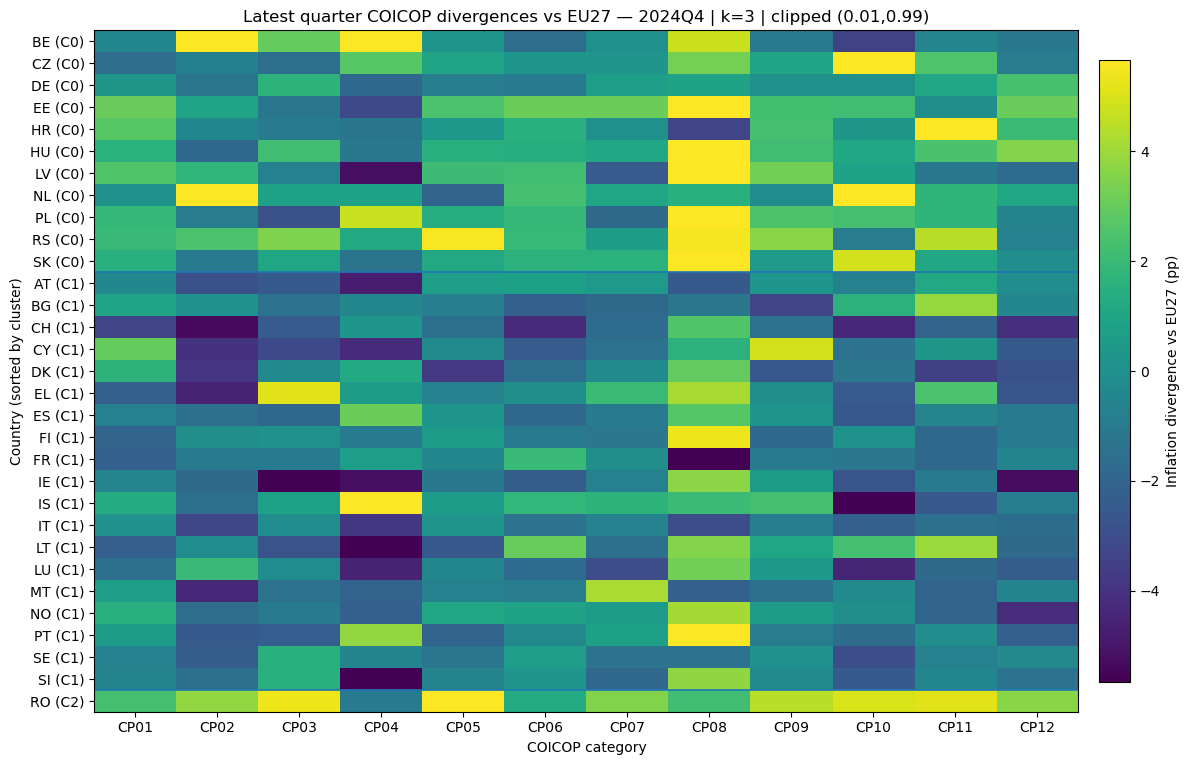

Saved figures:
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_latestQuarter_2024Q4_countryHeatmap.png
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_latestQuarter_2024Q4_countryHeatmap.pdf


In [17]:
# --- Save: latest-quarter country×COICOP heatmap + table (ml_clustering paths) ---

tablesClusteringDir = tablesDir / "ml_clustering"
figuresClusteringDir = figuresDir / "ml_clustering"
tablesClusteringDir.mkdir(parents=True, exist_ok=True)
figuresClusteringDir.mkdir(parents=True, exist_ok=True)

clipTag = "clip01_99"
fileStem = f"ml08_coicopClusters_{analysisWindowKey}_k{kChosen}_{clipTag}_vsEu27"

latestQuarterStr = str(latestQuarter)
tableOutPath = tablesClusteringDir / f"{fileStem}_latestQuarter_{latestQuarterStr}_countryMatrix.csv"

# Save underlying matrix table (geo + clusterId + CP values)
matDf.to_csv(tableOutPath, index=False)
print("Saved table:", tableOutPath)

# Recreate and save figure
M = matDf[cpVectorCols].to_numpy(dtype=float)
valueMaxAbs = float(np.quantile(np.abs(M), 0.95))
norm = TwoSlopeNorm(vmin=-valueMaxAbs, vcenter=0.0, vmax=valueMaxAbs)

fig, ax = plt.subplots(figsize=(12, max(4, 0.25 * len(matDf))))
im = ax.imshow(M, aspect="auto", norm=norm)

ax.set_title(f"Latest quarter COICOP divergences vs EU27 — {latestQuarterStr} | k={kChosen} | clipped (0.01,0.99)")
ax.set_xlabel("COICOP category")
ax.set_ylabel("Country (sorted by cluster)")

shortCols = []
for c in cpVectorCols:
    m = re.search(r"(CP\d{2})", c)
    shortCols.append(m.group(1) if m else c)
ax.set_xticks(range(len(shortCols)))
ax.set_xticklabels(shortCols)

yLabels = [f"{g} (C{cid})" for g, cid in zip(matDf["geo"], matDf["clusterId"])]
ax.set_yticks(range(len(yLabels)))
ax.set_yticklabels(yLabels)

clusterChangeIdx = np.where(matDf["clusterId"].to_numpy()[1:] != matDf["clusterId"].to_numpy()[:-1])[0]
for idx in clusterChangeIdx:
    ax.axhline(idx + 0.5, linewidth=1.2)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Inflation divergence vs EU27 (pp)")

plt.tight_layout()

figPathPng = figuresClusteringDir / f"{fileStem}_latestQuarter_{latestQuarterStr}_countryHeatmap.png"
figPathPdf = figuresClusteringDir / f"{fileStem}_latestQuarter_{latestQuarterStr}_countryHeatmap.pdf"
fig.savefig(figPathPng, dpi=200, bbox_inches="tight")
fig.savefig(figPathPdf, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" -", figPathPng)
print(" -", figPathPdf)


In [18]:
# --- Create interpretable cluster names from centroids (rule-based) ---

# Use centroidDf (original units, vs EU27) and short CP labels
centShort = centroidDf.copy().apply(pd.to_numeric, errors="coerce")
centShort.columns = [re.search(r"(CP\d{2})", c).group(1) for c in centShort.columns]

def makeClusterLabel(row: pd.Series, topK: int = 2) -> str:
    # top positive and negative contributors
    topPos = row.sort_values(ascending=False).head(topK)
    topNeg = row.sort_values(ascending=True).head(topK)

    # If centroid is broadly positive/negative across most categories, mark it
    fracPos = float((row > 0).mean())
    fracNeg = float((row < 0).mean())

    if fracPos >= 0.75:
        return f"BroadAboveEU ({', '.join(topPos.index)})"
    if fracNeg >= 0.75:
        return f"BroadBelowEU ({', '.join(topNeg.index)})"

    # Otherwise: mixed regime, label by dominant positives
    return f"Mixed ({', '.join(topPos.index)} up; {', '.join(topNeg.index)} down)"

clusterLabelMap = {int(cid): makeClusterLabel(centShort.loc[cid]) for cid in centShort.index}

dfClusterMeta = (
    pd.DataFrame({
        "clusterId": list(clusterLabelMap.keys()),
        "clusterLabel": list(clusterLabelMap.values()),
        "shareOverall": [float(clusterCounts.loc[cid, "share"]) for cid in clusterLabelMap.keys()],
    })
    .sort_values("clusterId")
    .reset_index(drop=True)
)

display(dfClusterMeta)
display(centShort.round(2))

# Apply labels to full labeled table (for dashboard)
dfClusterLabeledFinal = dfClusterLabeled.copy()
dfClusterLabeledFinal["clusterLabel"] = dfClusterLabeledFinal["clusterId"].map(clusterLabelMap)

display(dfClusterLabeledFinal[["geo", "timeQuarter", "clusterId", "clusterLabel"]].head(10))


,clusterId,clusterLabel,shareOverall
0,0,"BroadAboveEU (CP10, CP11)",0.308333
1,1,"BroadBelowEU (CP02, CP01)",0.572917
2,2,"BroadAboveEU (CP04, CP11)",0.118750


,CP01,CP02,CP03,CP04,CP05,CP06,CP07,CP08,CP09,CP10,CP11,CP12
clusterId,,,,,,,,,,,,
0,0.96,1.22,1.23,0.42,1.27,2.15,0.62,1.31,1.17,2.59,2.21,1.35
1,-1.56,-1.7,-0.87,-0.75,-0.9,-0.99,-0.59,-0.28,-0.69,-1.38,-0.81,-1.33
2,6.88,2.27,3.67,10.99,4.95,4.99,4.4,2.99,4.58,3.3,8.55,6.33


,geo,timeQuarter,clusterId,clusterLabel
0,AT,2021Q2,0,"BroadAboveEU (CP10, CP11)"
1,BE,2021Q2,1,"BroadBelowEU (CP02, CP01)"
2,BG,2021Q2,0,"BroadAboveEU (CP10, CP11)"
3,CH,2021Q2,1,"BroadBelowEU (CP02, CP01)"
4,CY,2021Q2,1,"BroadBelowEU (CP02, CP01)"
5,CZ,2021Q2,0,"BroadAboveEU (CP10, CP11)"
6,DE,2021Q2,1,"BroadBelowEU (CP02, CP01)"
7,DK,2021Q2,0,"BroadAboveEU (CP10, CP11)"
10,EA20,2021Q2,1,"BroadBelowEU (CP02, CP01)"
11,EE,2021Q2,0,"BroadAboveEU (CP10, CP11)"


In [19]:
# --- Final exports for dashboard use (ml_clustering paths) ---

tablesClusteringDir = tablesDir / "ml_clustering"
tablesClusteringDir.mkdir(parents=True, exist_ok=True)

clipTag = "clip01_99"
fileStem = f"ml08_coicopClusters_{analysisWindowKey}_k{kChosen}_{clipTag}_vsEu27"

# 1) Labels table (with label text)
labelsFinalOutPath = tablesClusteringDir / f"{fileStem}_labelsWithNames.csv"
dfClusterLabeledFinal[["geo", "timeQuarter", "clusterId", "clusterLabel"]].to_csv(labelsFinalOutPath, index=False)

# 2) Cluster meta (id -> name + overall share)
clusterMetaOutPath = tablesClusteringDir / f"{fileStem}_clusterMeta.csv"
dfClusterMeta.to_csv(clusterMetaOutPath, index=False)

# 3) Centroids table with short CP columns (interpretable)
centroidsShortOutPath = tablesClusteringDir / f"{fileStem}_centroids_shortCP.csv"
centShort.reset_index().rename(columns={"index": "clusterId"}).to_csv(centroidsShortOutPath, index=False)

print("Saved final clustering exports:")
print(" -", labelsFinalOutPath)
print(" -", clusterMetaOutPath)
print(" -", centroidsShortOutPath)


Saved final clustering exports:
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_labelsWithNames.csv
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_clusterMeta.csv
 - /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_centroids_shortCP.csv


Notebook08 summary — COICOP clustering (surgeAndAfter)

- We clustered countries by quarter using **COICOP CP01–CP12 inflation divergences vs EU27** for **2021Q2–2024Q4**.
- Preprocessing was designed for robustness and interpretability:
  - Dropped rows with missing CP vectors (UK in this window).
  - Applied **winsorization (clip 1%–99%)** on CP vectors to prevent rare extremes from dominating clustering.
  - Used **robust scaling** and fit **KMeans (k=3)** to obtain stable, interpretable archetypes.

- Key outputs produced in this notebook:
  - **Centroid heatmap**: cluster prototypes across CP01–CP12 (what each archetype “looks like”).
  - **Cluster share over time**: how the prevalence of archetypes changes through the surge and normalization.
  - **Transition matrix**: quarter-to-quarter persistence and switching pathways between archetypes.
  - **Latest quarter heatmap (2024Q4)**: country-level validation of cluster assignments.

- Dashboard-ready exports (saved under `reports/tables/ml_clustering/`):
  - `..._labelsWithNames.csv` — `geo, timeQuarter, clusterId, clusterLabel`
  - `..._clusterMeta.csv` — clusterId → label + overall share
  - `..._centroids_shortCP.csv` — centroids with CP01–CP12 columns

- Interpretation note:
  - Clusters are defined on **relative composition vs EU27**, so they capture “who deviates from the bloc in which categories,” not simply “high vs low inflation.”


In [20]:
# --- Optional: COICOP CP01–CP12 name mapping (dashboard/report friendly) ---

coicopNameMap = pd.DataFrame({
    "coicopCode": ["CP01","CP02","CP03","CP04","CP05","CP06","CP07","CP08","CP09","CP10","CP11","CP12"],
    "coicopName": [
        "Food & non-alcoholic beverages",
        "Alcoholic beverages & tobacco",
        "Clothing & footwear",
        "Housing, water, electricity, gas & other fuels",
        "Furnishings, household equipment & routine maintenance",
        "Health",
        "Transport",
        "Communication",
        "Recreation & culture",
        "Education",
        "Restaurants & hotels",
        "Miscellaneous goods & services",
    ],
})

display(coicopNameMap)

# Save mapping for reuse
tablesClusteringDir = tablesDir / "ml_clustering"
tablesClusteringDir.mkdir(parents=True, exist_ok=True)

coicopMapOutPath = tablesClusteringDir / "ml08_coicop_cp01_cp12_name_map.csv"
coicopNameMap.to_csv(coicopMapOutPath, index=False)

print("Saved:", coicopMapOutPath)


,coicopCode,coicopName
0,CP01,Food & non-alcoholic beverages
1,CP02,Alcoholic beverages & tobacco
2,CP03,Clothing & footwear
3,CP04,"Housing, water, electricity, gas & other fuels"
4,CP05,"Furnishings, household equipment & routine mai..."
5,CP06,Health
6,CP07,Transport
7,CP08,Communication
8,CP09,Recreation & culture
9,CP10,Education


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicop_cp01_cp12_name_map.csv


In [21]:
# --- Final clustering quality metrics (for the chosen setup) ---

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Assumes these exist from Notebook08:
# - dfClusterInput (pre-clip) and/or dfClusterInputClipped (post-clip)
# - cpVectorCols
# - rngSeed
# - kChosen
# - clipQuantileLow, clipQuantileHigh (optional)
# - XScaledClipped (optional)

# Rebuild XScaledClipped defensively (uses clipped version if available)
if "dfClusterInputClipped" in globals():
    XForMetrics = dfClusterInputClipped[cpVectorCols].to_numpy()
    clippingUsed = True
else:
    XForMetrics = dfClusterInput[cpVectorCols].to_numpy()
    clippingUsed = False

# Scale (robust, as used in the notebook)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
XScaledForMetrics = scaler.fit_transform(XForMetrics)

# Fit KMeans with final params (match your final notebook choice)
from sklearn.cluster import KMeans
kmCheck = KMeans(n_clusters=kChosen, random_state=rngSeed, n_init=50)
labelsCheck = kmCheck.fit_predict(XScaledForMetrics)

sil = float(silhouette_score(XScaledForMetrics, labelsCheck))
ch = float(calinski_harabasz_score(XScaledForMetrics, labelsCheck))
db = float(davies_bouldin_score(XScaledForMetrics, labelsCheck))
inertia = float(kmCheck.inertia_)

print("Final clustering metrics")
print("------------------------")
print("analysisWindowKey:", analysisWindowKey if "analysisWindowKey" in globals() else "surgeAndAfter")
print("kChosen:", kChosen)
print("scaling: RobustScaler")
if clippingUsed:
    low = clipQuantileLow if "clipQuantileLow" in globals() else 0.01
    high = clipQuantileHigh if "clipQuantileHigh" in globals() else 0.99
    print(f"clipping: enabled ({low}, {high})")
else:
    print("clipping: disabled")

print(f"silhouette:        {sil:.6f}  (higher better)")
print(f"calinskiHarabasz:  {ch:.6f}  (higher better)")
print(f"daviesBouldin:     {db:.6f}  (lower better)")
print(f"inertia:           {inertia:.6f}  (lower better)")


Final clustering metrics
------------------------
analysisWindowKey: surgeAndAfter
kChosen: 3
scaling: RobustScaler
clipping: enabled (0.01, 0.99)
silhouette:        0.193327  (higher better)
calinskiHarabasz:  159.111643  (higher better)
daviesBouldin:     1.718106  (lower better)
inertia:           2987.178173  (lower better)


### Clustering quality metrics (Silhouette, Calinski–Harabasz, Davies–Bouldin, Inertia)

- These metrics are **not “accuracy”**. In clustering we usually don’t have true labels, so we judge whether the grouping looks like **real structure** vs random splitting.

- **Silhouette (higher is better)**
  - Measures how well each point fits its own cluster compared to the nearest other cluster.
  - Rough intuition:
    - ~0.0 = clusters overlap a lot
    - higher = clearer separation

- **Calinski–Harabasz (higher is better)**
  - Compares “how far clusters are from each other” vs “how spread out points are inside clusters”.
  - Useful for comparing different `k` on the same dataset.

- **Davies–Bouldin (lower is better)**
  - Measures how much clusters overlap by comparing within-cluster scatter vs between-cluster separation.
  - Lower means clusters are more distinct.

- **Inertia (lower is better, but only meaningful relatively)**
  - This is KMeans’ objective: total within-cluster squared distance.
  - It always decreases as `k` increases, so you use it for an “elbow” check, not as a stand-alone winner.

- How we use them in this notebook:
  - We compute them mainly to compare **different k choices**.
  - We do **not** chase the best metric value at all costs—interpretability and stability also matter.

### Our final results (surgeAndAfter, k=3, RobustScaler, clipped 1%–99%)

- **silhouette = 0.193**
  - Interpretation: separation is **moderate / not super sharp**.
  - That’s expected because European inflation patterns are not cleanly separable into perfectly distinct “blobs”; they overlap.

- **calinskiHarabasz = 159.11**
  - Interpretation: there is **some real cluster structure**, but it’s not extreme.
  - Useful mostly as a baseline number to report for reproducibility.

- **daviesBouldin = 1.718**
  - Interpretation: clusters have **noticeable overlap**, but are still distinguishable.
  - Lower would be better; this value is reasonable for macro data with noisy boundaries.

- **inertia = 2987.18**
  - Interpretation: this is the final KMeans within-cluster compactness score for k=3.
  - We mainly keep it for record-keeping and for comparing to other `k` values (it will always drop if we increase k).

- Why we still accept this solution:
  - After clipping outliers, the clusters became **balanced** (no tiny outlier-only cluster).
  - The centroids and transition matrix show **interpretable and persistent regimes**, which is the main goal of this notebook.


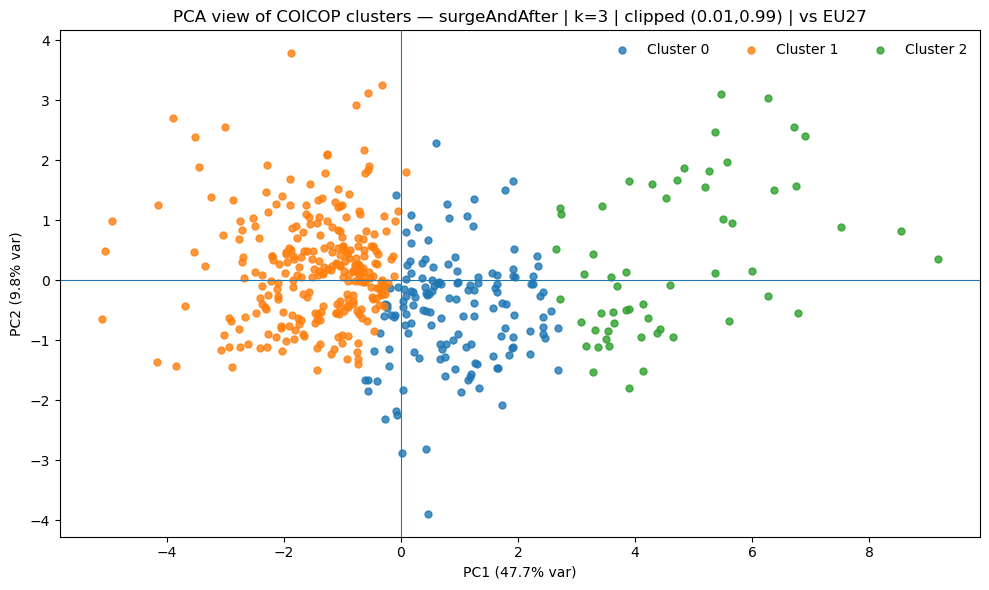

Explained variance ratio: [0.47692269 0.09773257]


In [23]:
# --- 2D clustering visualization (PCA projection) for k=3 ---

import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Rebuild XScaledClipped + labels defensively (uses your final setup)
if "dfClusterInputClipped" in globals():
    XUse = dfClusterInputClipped[cpVectorCols].to_numpy()
else:
    # fallback: clip on the fly if clipped df not present
    clipLower = dfClusterInput[cpVectorCols].quantile(0.01)
    clipUpper = dfClusterInput[cpVectorCols].quantile(0.99)
    XUse = dfClusterInput[cpVectorCols].clip(lower=clipLower, upper=clipUpper, axis=1).to_numpy()

scaler = RobustScaler()
XScaled = scaler.fit_transform(XUse)

# If you already have final labels, reuse; else refit KMeans with final params
if "dfClusterLabeledFinal" in globals():
    labels = dfClusterLabeledFinal["clusterId"].to_numpy()
elif "dfClusterLabeled" in globals() and "clusterId" in dfClusterLabeled.columns:
    labels = dfClusterLabeled["clusterId"].to_numpy()
else:
    kmTmp = KMeans(n_clusters=kChosen, random_state=rngSeed, n_init=50)
    labels = kmTmp.fit_predict(XScaled)

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=rngSeed)
X2 = pca.fit_transform(XScaled)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each cluster separately to get a clean legend (no manual colors)
for cid in sorted(np.unique(labels)):
    mask = labels == cid
    ax.scatter(X2[mask, 0], X2[mask, 1], s=25, alpha=0.8, label=f"Cluster {cid}")

ax.set_title(f"PCA view of COICOP clusters — {analysisWindowKey} | k={kChosen} | clipped (0.01,0.99) | vs EU27")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(frameon=False, ncol=3)
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


In [24]:
# --- Cluster → category signature table (top positive/negative CPs) ---

# Use short CP centroids (centShort) and COICOP names (coicopNameMap) if available
centSig = centShort.copy().apply(pd.to_numeric, errors="coerce")

# Ensure columns are CP01..CP12
assert all(c.startswith("CP") for c in centSig.columns), "Expected centShort columns to be CP01..CP12"

# Build name lookup
if "coicopNameMap" in globals():
    nameLookup = dict(zip(coicopNameMap["coicopCode"], coicopNameMap["coicopName"]))
else:
    nameLookup = {}

def fmtCats(series: pd.Series, idxList):
    parts = []
    for cp in idxList:
        cpName = nameLookup.get(cp, "")
        v = float(series.loc[cp])
        if cpName:
            parts.append(f"{cp} ({cpName})={v:.2f}")
        else:
            parts.append(f"{cp}={v:.2f}")
    return "; ".join(parts)

topK = 4  # change to 3/5 if you want shorter/longer lists

rows = []
for cid in centSig.index:
    s = centSig.loc[cid].copy()

    topPos = s.sort_values(ascending=False).head(topK)
    topNeg = s.sort_values(ascending=True).head(topK)

    fracPos = float((s > 0).mean())
    fracNeg = float((s < 0).mean())

    rows.append({
        "clusterId": int(cid),
        "clusterLabel": clusterLabelMap.get(int(cid), f"Cluster {cid}") if "clusterLabelMap" in globals() else f"Cluster {cid}",
        "shareOverall": float(dfClusterMeta.loc[dfClusterMeta["clusterId"] == int(cid), "shareOverall"].iloc[0]) if "dfClusterMeta" in globals() else np.nan,
        "fracCategoriesPositive": fracPos,
        "fracCategoriesNegative": fracNeg,
        "topPositiveCategories": fmtCats(s, topPos.index.tolist()),
        "topNegativeCategories": fmtCats(s, topNeg.index.tolist()),
    })

dfClusterCategorySignature = pd.DataFrame(rows).sort_values("clusterId").reset_index(drop=True)
display(dfClusterCategorySignature)

# Save
tablesClusteringDir = tablesDir / "ml_clustering"
tablesClusteringDir.mkdir(parents=True, exist_ok=True)

clipTag = "clip01_99"
fileStem = f"ml08_coicopClusters_{analysisWindowKey}_k{kChosen}_{clipTag}_vsEu27"
sigOutPath = tablesClusteringDir / f"{fileStem}_clusterCategorySignature_top{topK}.csv"

dfClusterCategorySignature.to_csv(sigOutPath, index=False)
print("Saved:", sigOutPath)


,clusterId,clusterLabel,shareOverall,fracCategoriesPositive,fracCategoriesNegative,topPositiveCategories,topNegativeCategories
0,0,"BroadAboveEU (CP10, CP11)",0.308333,1.0,0.0,CP10 (Education)=2.59; CP11 (Restaurants & hot...,"CP04 (Housing, water, electricity, gas & other..."
1,1,"BroadBelowEU (CP02, CP01)",0.572917,0.0,1.0,CP08 (Communication)=-0.28; CP07 (Transport)=-...,CP02 (Alcoholic beverages & tobacco)=-1.70; CP...
2,2,"BroadAboveEU (CP04, CP11)",0.118750,1.0,0.0,"CP04 (Housing, water, electricity, gas & other...",CP02 (Alcoholic beverages & tobacco)=2.27; CP0...


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_clustering/ml08_coicopClusters_surgeAndAfter_k3_clip01_99_vsEu27_clusterCategorySignature_top4.csv
